# 0. Setup

In [ ]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from wildfire_susceptibility.config.loader import ConfigLoader
from wildfire_susceptibility.viz.charts import plot_nan_coverage, plot_vif_correlation, plot_class_balance
from wildfire_susceptibility.viz.maps import render_all_factor_maps
from wildfire_susceptibility.viz.manifest import append_to_manifest
from wildfire_susceptibility.features.vegetation import VegetationBuilder
from wildfire_susceptibility.features.climate import ClimateBuilder

cfg_obj = ConfigLoader.load_experiment(name="baseline")
cfg = cfg_obj.model_dump(mode="python")
figures_dir = cfg_obj.base.figures_dir
dem_path = cfg_obj.base.output_dir / "topo_elevation.tif"

# 1. Helpers 

In [ ]:
def season_of_month(m: int) -> str:
    if m in [12, 1, 2]:
        return "WINTER"
    elif m in [3, 4, 5]:
        return "SPRING"
    elif m in [6, 7, 8]:
        return "SUMMER"
    elif m in [9, 10, 11]:
        return "FALL"
    return "?"


def load_climate_timeseries(config, var_name, year_range=None):
    """Full monthly time series (pre seasonal-average) for one HadUK variable,
    spatially averaged across Essex."""
    import xarray as xr
    data_dir = Path(config["data_sources"]["haduk"]["data_dir"]) / var_name
    files = sorted(data_dir.glob("*.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds[var_name]
    if year_range:
        da = da.sel(time=slice(f"{year_range[0]}-01-01", f"{year_range[1]}-12-31"))
    return da.mean(dim=["projection_x_coordinate", "projection_y_coordinate"]).to_series()


def temporal_eda_report(series, name, figures_dir):
    """STL decomposition + ADF stationarity test + ACF/PACF for one feature's
    time series. Saves figures, returns summary stats."""
    from statsmodels.tsa.seasonal import STL
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller

    fig, axes = plt.subplots(3, 1, figsize=(10, 9))
    series.plot(ax=axes[0], title=f"{name} — raw monthly series")

    stl = STL(series, period=12, robust=True).fit()
    stl.seasonal.plot(ax=axes[1], title="Seasonal component")
    stl.resid.plot(ax=axes[2], title="Residual (deseasonalized)")
    fig.tight_layout()

    out_dir = Path(figures_dir) / "temporal_eda"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{name}_decomposition.png", dpi=150)
    plt.close(fig)

    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), ax=ax1, lags=36)
    plot_pacf(series.dropna(), ax=ax2, lags=36)
    fig2.savefig(out_dir / f"{name}_acf_pacf.png", dpi=150)
    plt.close(fig2)

    adf_stat, adf_p, *_ = adfuller(series.dropna())
    return {"feature": name, "adf_stat": adf_stat, "adf_p": adf_p,
            "stationary": adf_p < 0.05}


def variance_decomposition(series, season_months):
    """% of total variance explained by season (between) vs within-season
    month-to-month variation. High between-season % justifies collapsing
    to a seasonal mean rather than keeping full monthly observations."""
    labels = series.index.month.map(
        lambda m: next(s for s, months in season_months.items() if m in months)
    )
    df = pd.DataFrame({"value": series.values, "season": labels})
    grand_mean = df["value"].mean()
    between = df.groupby("season")["value"].mean()
    ss_between = (df.groupby("season").size() * (between - grand_mean) ** 2).sum()
    ss_within = df.groupby("season")["value"].apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()
    return {"pct_variance_between_seasons": 100 * ss_between / (ss_between + ss_within)}


def render_nan_map(feature_paths: Dict[str, Path], figures_dir: Path, season=None) -> Path:
    """Composite map: count of NaN features per pixel, across a feature set."""
    arrays = []
    for path in feature_paths.values():
        with rasterio.open(path) as src:
            arrays.append(np.isnan(src.read(1)))
    nan_count = np.sum(arrays, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(np.ma.masked_equal(nan_count, 0), cmap="Reds", vmin=1, vmax=len(feature_paths))
    ax.set_title("NaN feature count per pixel" + (f" — {season}" if season else ""))
    ax.axis("off")
    plt.colorbar(im, ax=ax, label="# features NaN")

    out_path = Path(figures_dir) / (season or "static") / "eda" / "nan_map.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    append_to_manifest(figures_dir, out_path, "nan_coverage_map", "notebook.render_nan_map", season)
    return out_path


def global_morans_i(values_2d: np.ndarray, subsample_stride: int = 1):
    """Global Moran's I on a 2D array (NaN-aware, queen contiguity).
    subsample_stride > 1 downsamples the lattice for speed on full-res rasters."""
    from libpysal.weights import lat2W
    from esda.moran import Moran

    arr = values_2d[::subsample_stride, ::subsample_stride]
    flat = arr.flatten()
    valid_mask = ~np.isnan(flat)

    w = lat2W(*arr.shape, rook=False)
    w_valid_ids = [i for i in range(len(flat)) if valid_mask[i]]
    # esda/libpysal require a fully-connected weight matrix over valid ids;
    # simplest robust route: fill NaNs with the array mean so the lattice
    # stays complete, and note that filled cells contribute no new signal.
    filled = np.where(valid_mask, flat, np.nanmean(flat))
    mi = Moran(filled, w, permutations=999)
    return {"I": mi.I, "p_sim": mi.p_sim, "z_sim": mi.z_sim, "n_valid": int(valid_mask.sum())}

# 2. Fire Incident QA

In [ ]:
incidents_df = pd.read_csv("./data/bronze/incidents/OutdoorFIres_2009_2025.csv")
incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"], dayfirst=True)
incidents_df["Year"] = incidents_df["CallDateID"].dt.year
incidents_df["Month"] = incidents_df["CallDateID"].dt.month

print("Exact duplicate rows:", incidents_df.duplicated().sum())

same_day_loc = incidents_df.duplicated(
    subset=["CallDateID", "IncidentEasting", "IncidentNorthing"], keep=False
)
print("Same day+location duplicates:", same_day_loc.sum())

In [ ]:
# Drop same-day/same-location duplicates (the clearest re-logging signature)
before_n = len(incidents_df)
incidents_df = incidents_df.drop_duplicates(
    subset=["CallDateID", "IncidentEasting", "IncidentNorthing"]
).reset_index(drop=True)
print(f"Dropped {before_n - len(incidents_df):,} duplicate rows ({before_n:,} -> {len(incidents_df):,})")

yearly_counts = incidents_df["Year"].value_counts().sort_index()
yearly_counts.plot(kind="bar", figsize=(10, 4), title="Incidents per year (post-dedup)")
plt.show()

# 3. Seasonal distribution of fires

In [ ]:
temp = incidents_df[["Year", "Month"]].copy()
temp["Season"] = temp["Month"].apply(season_of_month)

print(temp["Season"].value_counts(normalize=True) * 100)

season_year_counts = temp.groupby(["Season", "Year"]).size().unstack(fill_value=0)
pct_season_year_counts = 100 * season_year_counts / season_year_counts.sum(axis=0)

df_long = pct_season_year_counts.reset_index().melt(
    id_vars="Season", var_name="Year", value_name="Percent (%)"
)
df_long["Year"] = df_long["Year"].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_long, x="Year", y="Percent (%)", hue="Season", marker="o")
plt.title("Seasonal incident share by year")
plt.xticks(sorted(df_long["Year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
temp = incidents_df[["Year", "Month"]].copy()
temp["Season"] = temp["Month"].apply(season_of_month)

print(temp["Season"].value_counts(normalize=True) * 100)

season_year_counts = temp.groupby(["Season", "Year"]).size().unstack(fill_value=0)
pct_season_year_counts = 100 * season_year_counts / season_year_counts.sum(axis=0)

df_long = pct_season_year_counts.reset_index().melt(
    id_vars="Season", var_name="Year", value_name="Percent (%)"
)
df_long["Year"] = df_long["Year"].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_long, x="Year", y="Percent (%)", hue="Season", marker="o")
plt.title("Seasonal incident share by year")
plt.xticks(sorted(df_long["Year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

# 4. Temporal EDA per feature (univariate + variance decomposition)

In [ ]:
gridsize = 200

In [ ]:
season_months = cfg["seasons"]["definitions"]  # {"spring": [...], ...}

# --- NDVI ---
veg_builder = VegetationBuilder(cfg)
ndvi_long = veg_builder.eda_debug()

plt.figure(figsize=(10, 6))
plt.hexbin(ndvi_long["time"], ndvi_long["ndvi"], gridsize=gridsize, cmap="inferno", mincnt=1)
plt.colorbar(label="Count of series")
plt.title("NDVI — seasonal density over time")
plt.show()

In [ ]:
climate_vars = cfg["data_sources"]["haduk"]["sources"]  # tas, tasmax, tasmin, rainfall, sfcWind, hurs

In [ ]:
temporal_summary = []

for var in climate_vars:
    series = load_climate_timeseries(cfg, var, year_range=cfg["processing"]["training_years"])
    stats = temporal_eda_report(series, var, figures_dir)
    var_decomp = variance_decomposition(series, season_months)
    temporal_summary.append({**stats, **var_decomp})

temporal_summary_df = pd.DataFrame(temporal_summary)
temporal_summary_df

In [ ]:
haduk_builder = ClimateBuilder(cfg)

for var in climate_vars:
    var_arr = haduk_builder.eda_debug(var)   # (n_days, H, W)

    plt.figure(figsize=(10, 6))
    plt.hexbin(var_arr["time"], var_arr[var], gridsize=gridsize, cmap="inferno", mincnt=1)
    plt.colorbar(label="Count of series")
    plt.title(f"{var} — seasonal density over time")
    plt.show()

In [ ]:
# incident_summary = []

#     stats = temporal_eda_report()
#     var_decomp = variance_decomposition(series, season_months)
#     incident_summary
#     stats = temporal_eda_report(series, var, figures_dir)
#     var_decomp = variance_decomposition(series, season_months)
#     temporal_summary.append({**stats, **var_decomp})

# temporal_summary_df = pd.DataFrame(temporal_summary)
# temporal_summary_df

# 5. Nan Analysis

In [ ]:
# for season in cfg_obj.seasons.active:
#     df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
#     feature_cols = [c for c in df.columns if c != "label"]
#     feature_arrays = {c: df[c].values for c in feature_cols}
#     plot_nan_coverage(feature_arrays, figures_dir, season=season)

#     nan_summary = df[feature_cols].isna().sum().sort_values(ascending=False)
#     n_rows_any_nan = df[feature_cols].isna().any(axis=1).sum()
#     print(f"[{season}] rows with >=1 NaN feature: {n_rows_any_nan:,} / {len(df):,}")
#     print(nan_summary[nan_summary > 0])

In [ ]:
# Spatial NaN map — confirms the three documented NaN sources are spatially
# distinct (coastal/estuary mask, flat-terrain SRTM no-data, scattered cloud
# contamination), rather than overlapping in a way that would compound loss.
for season in cfg_obj.seasons.active:
    feature_paths = {
        "tasmax": cfg_obj.base.output_dir / f"meteo_tasmax_{season}_train.tif",
        "slope":  cfg_obj.base.output_dir / "topo_slope.tif",
        "ndvi":   cfg_obj.base.output_dir / f"ndvi_{season}_train.tif",
    }
    feature_paths = {k: v for k, v in feature_paths.items() if v.exists()}
    if feature_paths:
        render_nan_map(feature_paths, figures_dir, season=season)

# 6. VIF / Correlation / Class balance

In [ ]:
for season in cfg_obj.seasons.active:
    df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
    feature_cols = [c for c in df.columns if c not in ["label", "_x", "_y", "tas", "tasmin"]]
    plot_vif_correlation(
        df, feature_cols, figures_dir, season=season, vif_threshold=10.0, corr_threshold=0.8,
    )

# Class balance before/after label cleaning (uncomment once risk_labels_clean_*.tif exist)
# for season in cfg_obj.seasons.active:
#     with rasterio.open(cfg_obj.base.output_dir / f"risk_labels_{cfg_obj.labels.density_method}_{cfg_obj.labels.classify_method}_{season}_train.tif") as src:
#         before = src.read(1)
#     with rasterio.open(cfg_obj.base.output_dir / f"risk_labels_clean_{season}_train.tif") as src:
#         after = src.read(1)
#     plot_class_balance(before, after, figures_dir, season=season)

In [ ]:
# Coefficient of variation per feature, per season — quick scan for
# near-constant features that would add little discriminative signal.
cov_by_season = {}
for season in cfg_obj.seasons.active:
    df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
    feature_cols = [c for c in df.columns if c != "label"]
    cov_by_season[season] = df[feature_cols].std() / df[feature_cols].mean()

pd.concat(cov_by_season, axis=1).T

# 7. Factor maps

In [ ]:
static_paths = {
    "elevation": cfg_obj.base.output_dir / "topo_elevation.tif",
    "slope": cfg_obj.base.output_dir / "topo_slope.tif",
    "aspect": cfg_obj.base.output_dir / "topo_aspect.tif",
    "d_rivers": cfg_obj.base.output_dir / "dist_rivers.tif",
    "d_roads": cfg_obj.base.output_dir / "dist_roads.tif",
    "d_buildings": cfg_obj.base.output_dir / "dist_buildings.tif",
    "land_use": cfg_obj.base.output_dir / "landuse_class.tif",
}
render_all_factor_maps(static_paths, dem_path, figures_dir)

for season in cfg_obj.seasons.active:
    seasonal_paths = {
        "tas": cfg_obj.base.output_dir / f"meteo_tas_{season}_train.tif",
        "tasmax": cfg_obj.base.output_dir / f"meteo_tasmax_{season}_train.tif",
        "tasmin": cfg_obj.base.output_dir / f"meteo_tasmin_{season}_train.tif",
        "hurs": cfg_obj.base.output_dir / f"meteo_hurs_{season}_train.tif",
        "sfcWind": cfg_obj.base.output_dir / f"meteo_sfcWind_{season}_train.tif",
        "rainfall": cfg_obj.base.output_dir / f"meteo_rainfall_{season}_train.tif",
        "d_fires": cfg_obj.base.output_dir / f"dist_fires_{season}.tif",
        "ndvi": cfg_obj.base.output_dir / f"ndvi_{season}_train.tif",
    }
    seasonal_paths = {k: v for k, v in seasonal_paths.items() if v.exists()}
    render_all_factor_maps(seasonal_paths, dem_path, figures_dir, season=season)

# 8. Spatial EDA

In [ ]:
# Global Moran's I on fire density — direct evidence for spatial
# autocorrelation motivating the stratified spatial block CV contribution.
for season in cfg_obj.seasons.active:
    density_path = cfg_obj.base.output_dir / f"fire_density_conv_{season}_train.tif"
    if not density_path.exists():
        continue
    with rasterio.open(density_path) as src:
        density = src.read(1)
    result = global_morans_i(density, subsample_stride=4)  # stride for speed on full-res grid
    print(f"[{season}] Moran's I = {result['I']:.4f} (p={result['p_sim']:.4f}, n={result['n_valid']:,})")

Distance-band Moran's I correlogram, empirically justifies spatial_block_size_m / spatial_buffer_m (configs/modeling.yaml)

In [ ]:
def spatial_correlogram(coords: np.ndarray, values: np.ndarray, band_edges, permutations: int = 199):
    """Moran's I per distance band (ring/annulus weights over a point
    sample, row-standardized) rather than one fixed-lag lattice weight.
    band_edges are ring boundaries in metres, e.g. [0, 500, 1000, ...].
    The autocorrelation range is the band where I drops to ~0 / loses
    significance."""
    from libpysal.weights import full2W
    from esda.moran import Moran
    from scipy.spatial.distance import pdist, squareform

    dist_matrix = squareform(pdist(coords))
    rows = []
    for lo, hi in zip(band_edges[:-1], band_edges[1:]):
        band = (dist_matrix >= lo) & (dist_matrix < hi)
        np.fill_diagonal(band, False)
        n_links = int(band.sum())
        if n_links == 0:
            rows.append({"lag_lo_m": lo, "lag_hi_m": hi, "I": np.nan, "p_sim": np.nan, "n_links": 0})
            continue
        w = full2W(band.astype(float), silence_warnings=True)
        w.transform = "r"
        mi = Moran(values, w, permutations=permutations)
        rows.append({"lag_lo_m": lo, "lag_hi_m": hi, "I": mi.I, "p_sim": mi.p_sim, "n_links": n_links})
    return pd.DataFrame(rows)


def sample_raster_points(path, n_sample, rng):
    """Random sample of up to n_sample valid (non-NaN) pixel centers from a
    raster: returns (coords[N,2] in the raster's CRS units, values[N])."""
    with rasterio.open(path) as src:
        arr = src.read(1)
        transform = src.transform
    rows, cols = np.where(~np.isnan(arr))
    idx = rng.choice(len(rows), size=min(n_sample, len(rows)), replace=False)
    rows, cols = rows[idx], cols[idx]
    xs, ys = rasterio.transform.xy(transform, rows, cols)
    return np.column_stack([xs, ys]), arr[rows, cols].astype(float)

In [ ]:

CORRELOGRAM_BAND_EDGES = [
    0, 150, 300, 500, 750, 1000, 
    1500, 2000, 3000, 4000, 5500, 7000, 9000, 
    11000, 14000, 18000, 23000, 30000
]
CORRELOGRAM_N_SAMPLE = 4000
rng = np.random.default_rng(42)

correlogram_frames = []
for season in cfg_obj.seasons.active:
    layer_paths = {
        # "fire_density_conv (target proxy)": cfg_obj.base.output_dir / f"fire_density_conv_{season}_train.tif",
        "fire_density_kde (target proxy)": cfg_obj.base.output_dir / f"fire_density_kde_{season}_train.tif",
        "elevation": cfg_obj.base.output_dir / "topo_elevation.tif",
        "ndvi": cfg_obj.base.output_dir / f"ndvi_{season}_train.tif",
        "tasmax": cfg_obj.base.output_dir / f"meteo_tasmax_{season}_train.tif",
    }
    for layer_name, path in layer_paths.items():
        if not path.exists():
            continue
        coords, values = sample_raster_points(path, CORRELOGRAM_N_SAMPLE, rng)
        df = spatial_correlogram(coords, values, CORRELOGRAM_BAND_EDGES)
        df["season"], df["layer"] = season, layer_name
        correlogram_frames.append(df)

        below_005 = df.loc[df["I"] < 0.05, "lag_lo_m"]
        practical_range = f"{below_005.min():.0f}m" if len(below_005) else "not reached within 30km"
        print(f"[{season}] {layer_name}: I<0.05 by {practical_range}")

correlogram_df = pd.concat(correlogram_frames, ignore_index=True) if correlogram_frames else pd.DataFrame()
correlogram_df

[summer] fire_density_conv (target proxy): I<0.05 by 4000m
[summer] elevation: I<0.05 by not reached within 30km
[summer] ndvi: I<0.05 by 14000m
[summer] tasmax: I<0.05 by 18000m


,lag_lo_m,lag_hi_m,I,p_sim,n_links,season,layer
0,0,150,0.232323,0.010,334,summer,fire_density_conv (target proxy)
1,150,300,0.652408,0.005,996,summer,fire_density_conv (target proxy)
2,300,500,0.390654,0.005,2320,summer,fire_density_conv (target proxy)
3,500,750,0.391157,0.005,4366,summer,fire_density_conv (target proxy)
4,750,1000,0.283079,0.005,6230,summer,fire_density_conv (target proxy)
...,...,...,...,...,...,...,...
63,9000,11000,0.410476,0.005,430182,summer,tasmax
64,11000,14000,0.317074,0.005,749700,summer,tasmax
65,14000,18000,0.160088,0.005,1157592,summer,tasmax
66,18000,23000,-0.010032,0.005,1630044,summer,tasmax


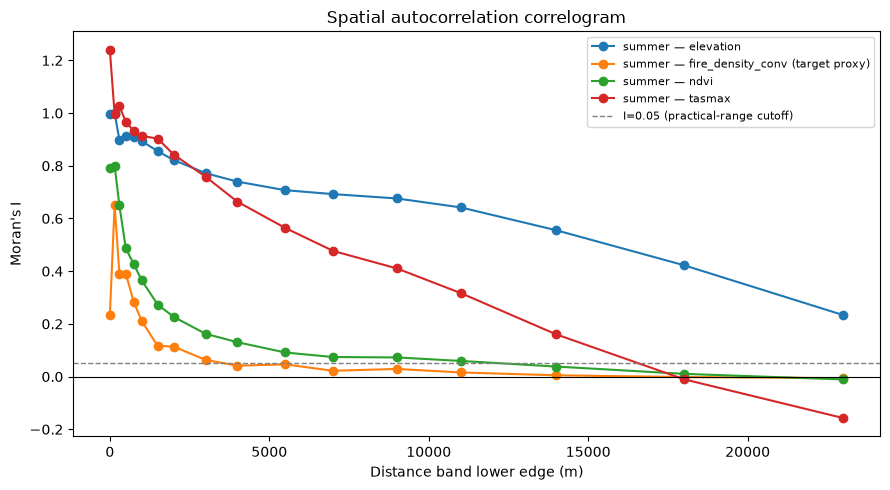

In [ ]:
if not correlogram_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    for (season, layer), grp in correlogram_df.groupby(["season", "layer"]):
        ax.plot(grp["lag_lo_m"], grp["I"], marker="o", label=f"{season} — {layer}")
    ax.axhline(0.05, color="grey", linestyle="--", linewidth=1, label="I=0.05 (practical-range cutoff)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Distance band lower edge (m)")
    ax.set_ylabel("Moran's I")
    ax.set_title("Spatial autocorrelation correlogram")
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()

    out_path = Path(figures_dir) / "eda" / "spatial_correlogram.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150)
    append_to_manifest(figures_dir, out_path, "spatial_autocorrelation_correlogram", "notebook.spatial_correlogram")
    plt.show()